In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('ggplot')
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

# Paths
DATA_DIR = '../data/raw/elliptic_bitcoin_data'
FIG_DIR = '../outputs/figures/elliptic_bitcoin_data'
os.makedirs(FIG_DIR, exist_ok=True)

# Auto-detect if dataset is nested in a subfolder
candidates = [
    DATA_DIR,
    os.path.join(DATA_DIR, 'elliptic_bitcoin_dataset'),
]
for path in candidates:
    if os.path.isfile(os.path.join(path, 'elliptic_txs_features.csv')):
        DATA_DIR = path
        break

print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Files found: {os.listdir(DATA_DIR)}")
print("Setup complete.")

Data directory: /Users/kuijun/Desktop/spring-2026-spec-proj/data/raw/elliptic_bitcoin_data/elliptic_bitcoin_dataset
Files found: ['elliptic_txs_classes.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_features.csv']
Setup complete.


In [3]:
# Load the three core files with optimized dtypes
features_df = pd.read_csv(
    os.path.join(DATA_DIR, 'elliptic_txs_features.csv'),
    header=None,
    dtype={0: np.int64, **{i: np.float32 for i in range(1, 167)}}
)
classes_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_classes.csv'))
edgelist_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv'))

# Column 0 = txId, Column 1 = time step
num_agg = 72
num_local = features_df.shape[1] - 2 - num_agg

features_df.columns = ['txId', 'time_step'] + [f'local_feat_{i}' for i in range(num_local)] + [f'agg_feat_{i}' for i in range(num_agg)]

print(f"Features shape: {features_df.shape}")
print(f"Classes shape:  {classes_df.shape}")
print(f"Edgelist shape: {edgelist_df.shape}")
print(f"Local features: {num_local}, Aggregated features: {num_agg}")
print(f"Memory usage: {features_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
features_df.head()

Features shape: (203769, 167)
Classes shape:  (203769, 2)
Edgelist shape: (234355, 2)
Local features: 93, Aggregated features: 72
Memory usage: 130.6 MB


,txId,time_step,local_feat_0,local_feat_1,local_feat_2,local_feat_3,local_feat_4,local_feat_5,local_feat_6,local_feat_7,...,agg_feat_62,agg_feat_63,agg_feat_64,agg_feat_65,agg_feat_66,agg_feat_67,agg_feat_68,agg_feat_69,agg_feat_70,agg_feat_71
0,230425980,1.0,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1.0,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1.0,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1.0,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782743,12.414557,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1.0,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [4]:
# Merge features with classes
df = features_df.merge(classes_df, on='txId', how='left')

# Map class labels: 1 = illicit, 2 = licit, unknown = unknown
df['class'] = df['class'].map({'1': 'illicit', '2': 'licit', 'unknown': 'unknown'})

print(f"Merged dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\nTime steps: {int(df['time_step'].min())} to {int(df['time_step'].max())} ({int(df['time_step'].nunique())} total)")
df.head()

Merged dataset shape: (203769, 168)

Class distribution:
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

Time steps: 1 to 49 (49 total)


,txId,time_step,local_feat_0,local_feat_1,local_feat_2,local_feat_3,local_feat_4,local_feat_5,local_feat_6,local_feat_7,...,agg_feat_63,agg_feat_64,agg_feat_65,agg_feat_66,agg_feat_67,agg_feat_68,agg_feat_69,agg_feat_70,agg_feat_71,class
0,230425980,1.0,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1.0,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1.0,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1.0,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782743,12.414557,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit
4,230460314,1.0,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


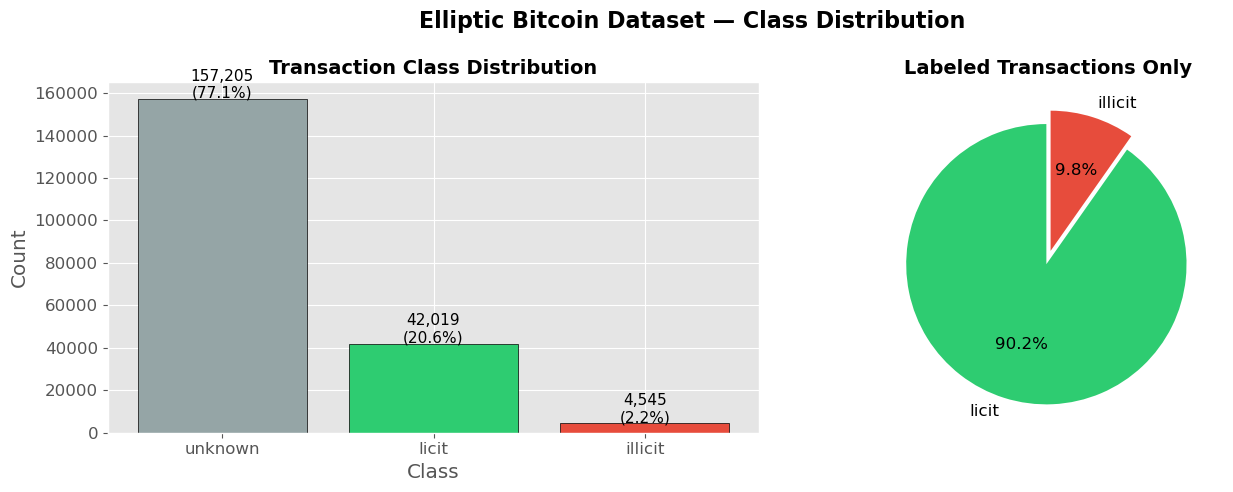

Saved: class_distribution.png


In [8]:
# ── 1. Overall Class Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['class'].value_counts()
colors = {'illicit': '#e74c3c', 'licit': '#2ecc71', 'unknown': '#95a5a6'}
bar_colors = [colors[c] for c in class_counts.index]

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 500, f'{cnt:,}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Pie chart (labeled only)
labeled_df = df[df['class'] != 'unknown']
labeled_counts = labeled_df['class'].value_counts()
axes[1].pie(labeled_counts, labels=labeled_counts.index,
            colors=[colors[c] for c in labeled_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            explode=[0.05] * len(labeled_counts))
axes[1].set_title('Labeled Transactions Only', fontsize=14, fontweight='bold')

fig.suptitle('Elliptic Bitcoin Dataset — Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

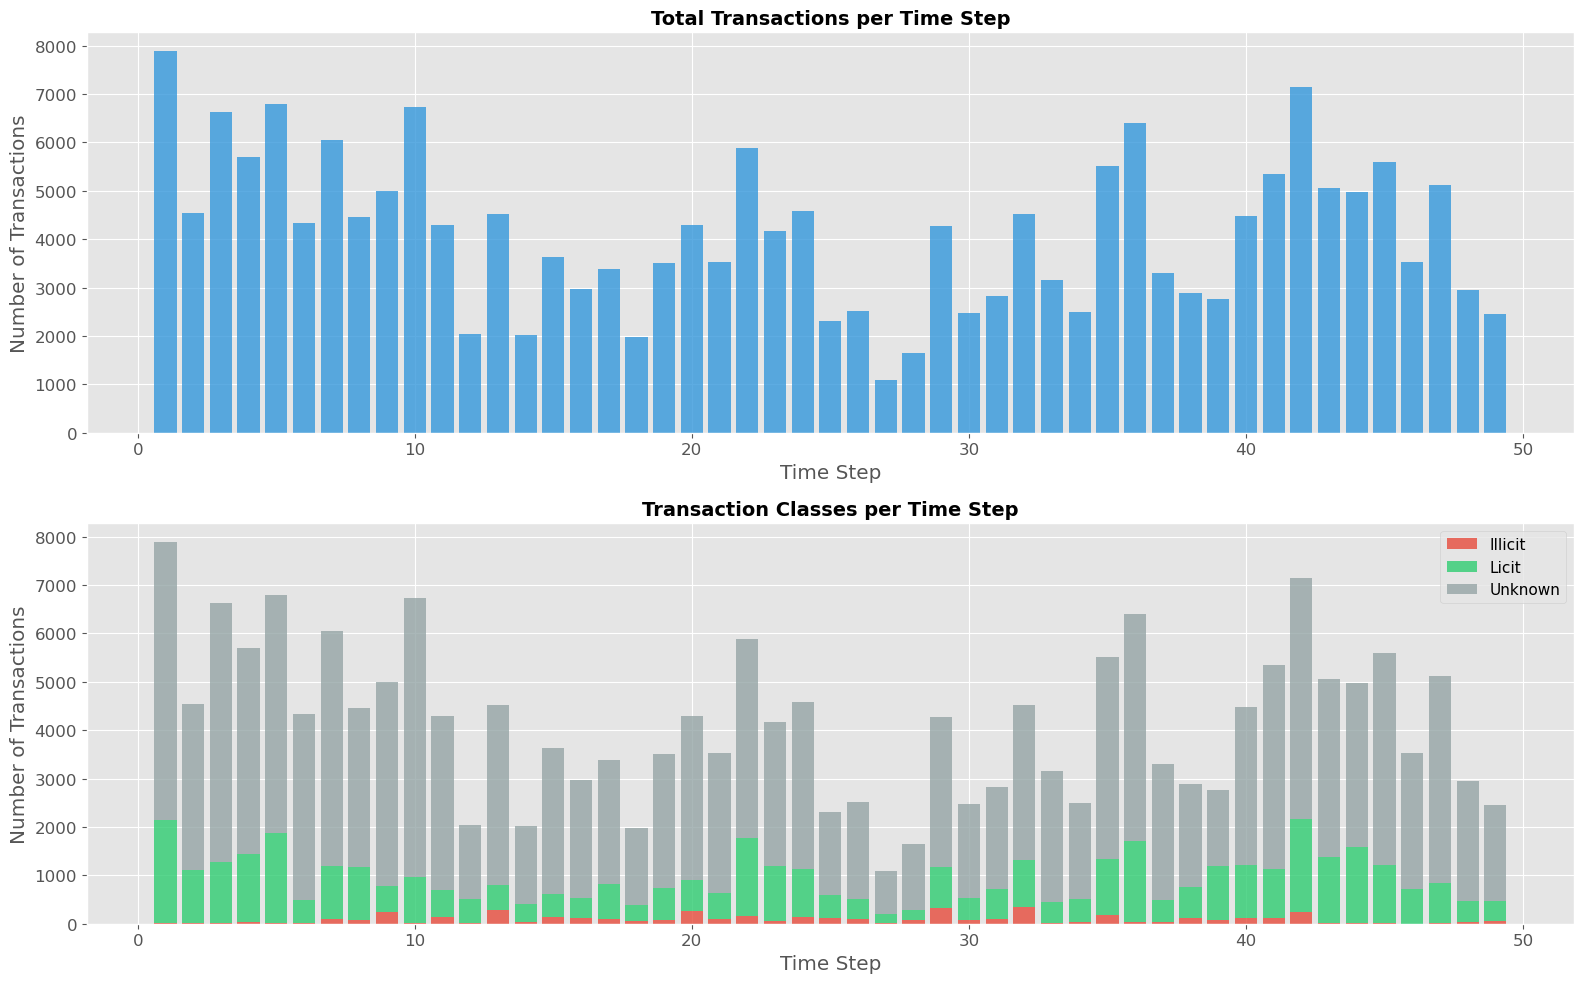

Saved: temporal_distribution.png


In [9]:
# ── 2. Transactions Over Time Steps ──
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Total transactions per time step
tx_per_step = df.groupby('time_step').size()
axes[0].bar(tx_per_step.index, tx_per_step.values, color='#3498db', alpha=0.8, edgecolor='none')
axes[0].set_title('Total Transactions per Time Step', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Number of Transactions')

# Illicit vs Licit over time
illicit_per_step = df[df['class'] == 'illicit'].groupby('time_step').size()
licit_per_step = df[df['class'] == 'licit'].groupby('time_step').size()
unknown_per_step = df[df['class'] == 'unknown'].groupby('time_step').size()

all_steps = range(1, int(df['time_step'].max()) + 1)
axes[1].bar(all_steps, [illicit_per_step.get(s, 0) for s in all_steps],
            label='Illicit', color='#e74c3c', alpha=0.8)
axes[1].bar(all_steps, [licit_per_step.get(s, 0) for s in all_steps],
            bottom=[illicit_per_step.get(s, 0) for s in all_steps],
            label='Licit', color='#2ecc71', alpha=0.8)
axes[1].bar(all_steps, [unknown_per_step.get(s, 0) for s in all_steps],
            bottom=[illicit_per_step.get(s, 0) + licit_per_step.get(s, 0) for s in all_steps],
            label='Unknown', color='#95a5a6', alpha=0.8)
axes[1].set_title('Transaction Classes per Time Step', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Number of Transactions')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'temporal_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: temporal_distribution.png")

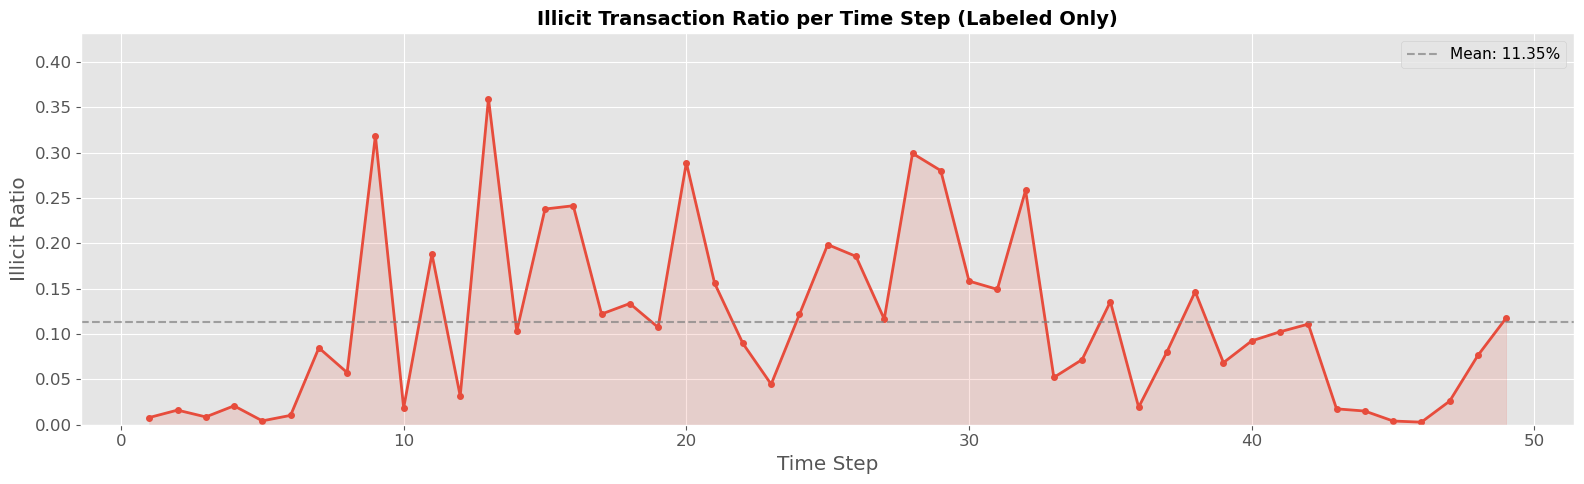

Saved: illicit_ratio_over_time.png


In [10]:
# ── 3. Illicit Ratio Over Time ──
fig, ax = plt.subplots(figsize=(16, 5))

illicit_ratio = []
for s in all_steps:
    step_df = df[(df['time_step'] == s) & (df['class'] != 'unknown')]
    if len(step_df) > 0:
        ratio = len(step_df[step_df['class'] == 'illicit']) / len(step_df)
    else:
        ratio = 0
    illicit_ratio.append(ratio)

ax.plot(all_steps, illicit_ratio, color='#e74c3c', linewidth=2, marker='o', markersize=4)
ax.axhline(y=np.mean(illicit_ratio), color='gray', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(illicit_ratio):.2%}')
ax.fill_between(all_steps, illicit_ratio, alpha=0.15, color='#e74c3c')
ax.set_title('Illicit Transaction Ratio per Time Step (Labeled Only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Step')
ax.set_ylabel('Illicit Ratio')
ax.set_ylim(0, max(illicit_ratio) * 1.2)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'illicit_ratio_over_time.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: illicit_ratio_over_time.png")

In [11]:
# ── 4. Transaction Graph Analysis ──
print("Building transaction graph...")
G = nx.from_pandas_edgelist(edgelist_df, source='txId1', target='txId2', create_using=nx.DiGraph())

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")
print(f"Average in-degree:  {np.mean([d for _, d in G.in_degree()]):.2f}")
print(f"Average out-degree: {np.mean([d for _, d in G.out_degree()]):.2f}")
print(f"Density: {nx.density(G):.6f}")

# Number of weakly connected components
num_components = nx.number_weakly_connected_components(G)
largest_cc = max(nx.weakly_connected_components(G), key=len)
print(f"Weakly connected components: {num_components:,}")
print(f"Largest component size: {len(largest_cc):,} ({len(largest_cc)/G.number_of_nodes()*100:.1f}%)")

Building transaction graph...
Number of nodes: 203,769
Number of edges: 234,355
Average in-degree:  1.15
Average out-degree: 1.15
Density: 0.000006
Weakly connected components: 49
Largest component size: 7,880 (3.9%)


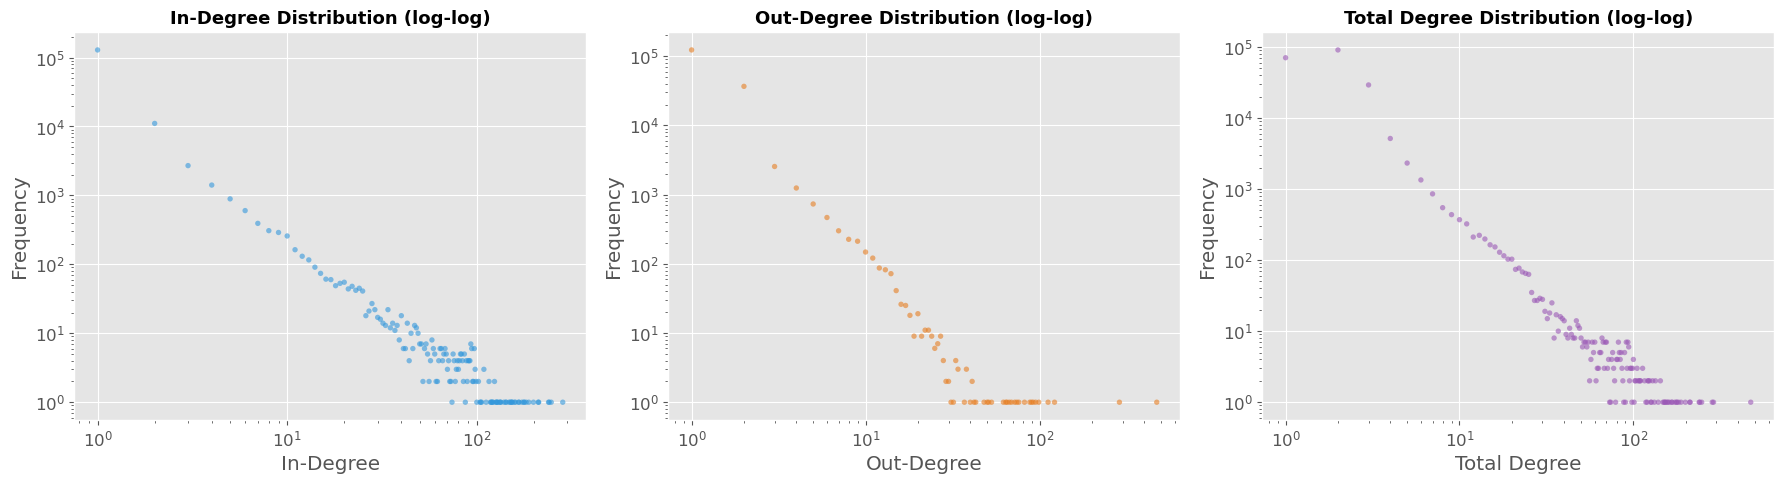

Saved: degree_distribution.png


In [12]:
# ── 5. Degree Distribution ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]
total_degrees = [d for _, d in G.degree()]

for ax, degrees, title, color in zip(
    axes,
    [in_degrees, out_degrees, total_degrees],
    ['In-Degree', 'Out-Degree', 'Total Degree'],
    ['#3498db', '#e67e22', '#9b59b6']
):
    degree_counts = Counter(degrees)
    deg_vals = sorted(degree_counts.keys())
    deg_freqs = [degree_counts[d] for d in deg_vals]

    ax.scatter(deg_vals, deg_freqs, c=color, alpha=0.6, s=15, edgecolors='none')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{title} Distribution (log-log)', fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'degree_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: degree_distribution.png")

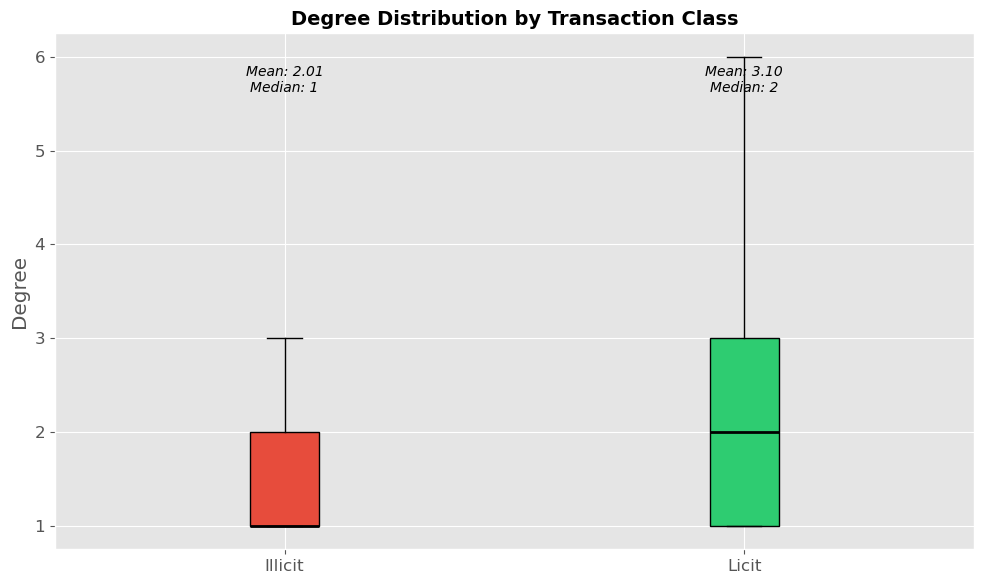

Saved: degree_by_class.png


In [13]:
# ── 6. Degree Comparison: Illicit vs Licit ──
node_class = dict(zip(df['txId'], df['class']))
degree_dict = dict(G.degree())

degree_by_class = {'illicit': [], 'licit': []}
for node, deg in degree_dict.items():
    cls = node_class.get(node, 'unknown')
    if cls in degree_by_class:
        degree_by_class[cls].append(deg)

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([degree_by_class['illicit'], degree_by_class['licit']],
                labels=['Illicit', 'Licit'], patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')

ax.set_title('Degree Distribution by Transaction Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Degree')

# Add mean annotations
for i, cls in enumerate(['illicit', 'licit']):
    mean_val = np.mean(degree_by_class[cls])
    median_val = np.median(degree_by_class[cls])
    ax.text(i + 1, ax.get_ylim()[1] * 0.9,
            f'Mean: {mean_val:.2f}\nMedian: {median_val:.0f}',
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'degree_by_class.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: degree_by_class.png")

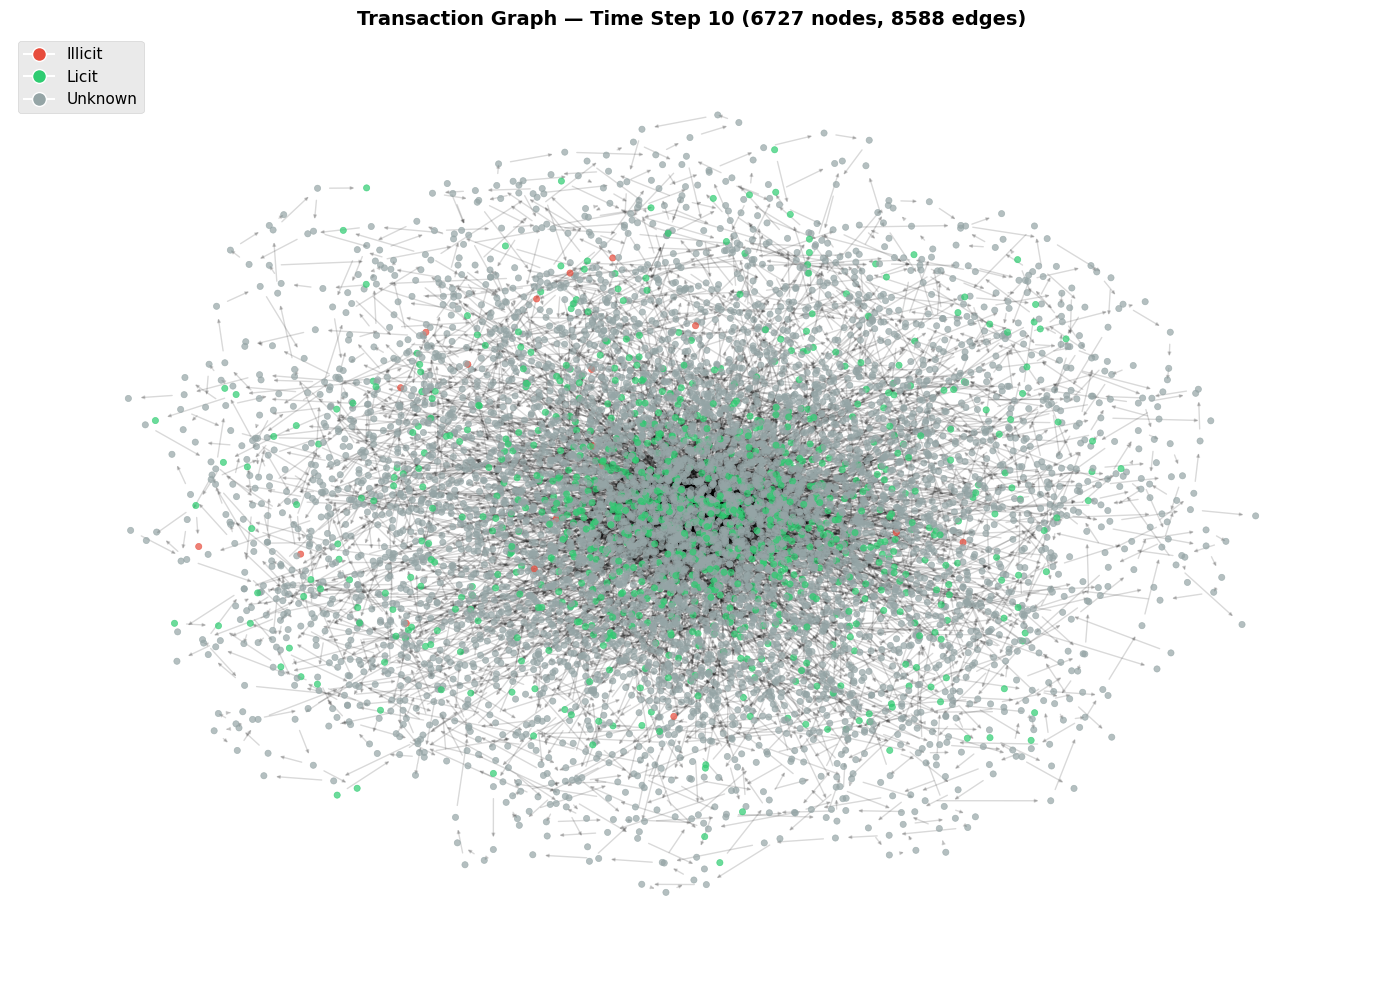

Saved: transaction_subgraph.png


In [14]:
# ── 7. Subgraph Visualization (single time step) ──
sample_step = 10
step_nodes = set(df[df['time_step'] == sample_step]['txId'].values)
subG = G.subgraph([n for n in G.nodes() if n in step_nodes]).copy()

node_colors = []
for n in subG.nodes():
    cls = node_class.get(n, 'unknown')
    if cls == 'illicit':
        node_colors.append('#e74c3c')
    elif cls == 'licit':
        node_colors.append('#2ecc71')
    else:
        node_colors.append('#95a5a6')

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subG, seed=42, k=0.5)
nx.draw_networkx_edges(subG, pos, alpha=0.15, arrows=True, arrowsize=5, ax=ax)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=20, alpha=0.7, ax=ax)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Illicit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Licit'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Unknown'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.set_title(f'Transaction Graph — Time Step {sample_step} ({subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'transaction_subgraph.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: transaction_subgraph.png")

Selected 9 features from 90 valid features
Top features: ['local_feat_52', 'local_feat_54', 'local_feat_89', 'local_feat_88', 'local_feat_53', 'local_feat_51', 'local_feat_90', 'local_feat_58', 'local_feat_64']


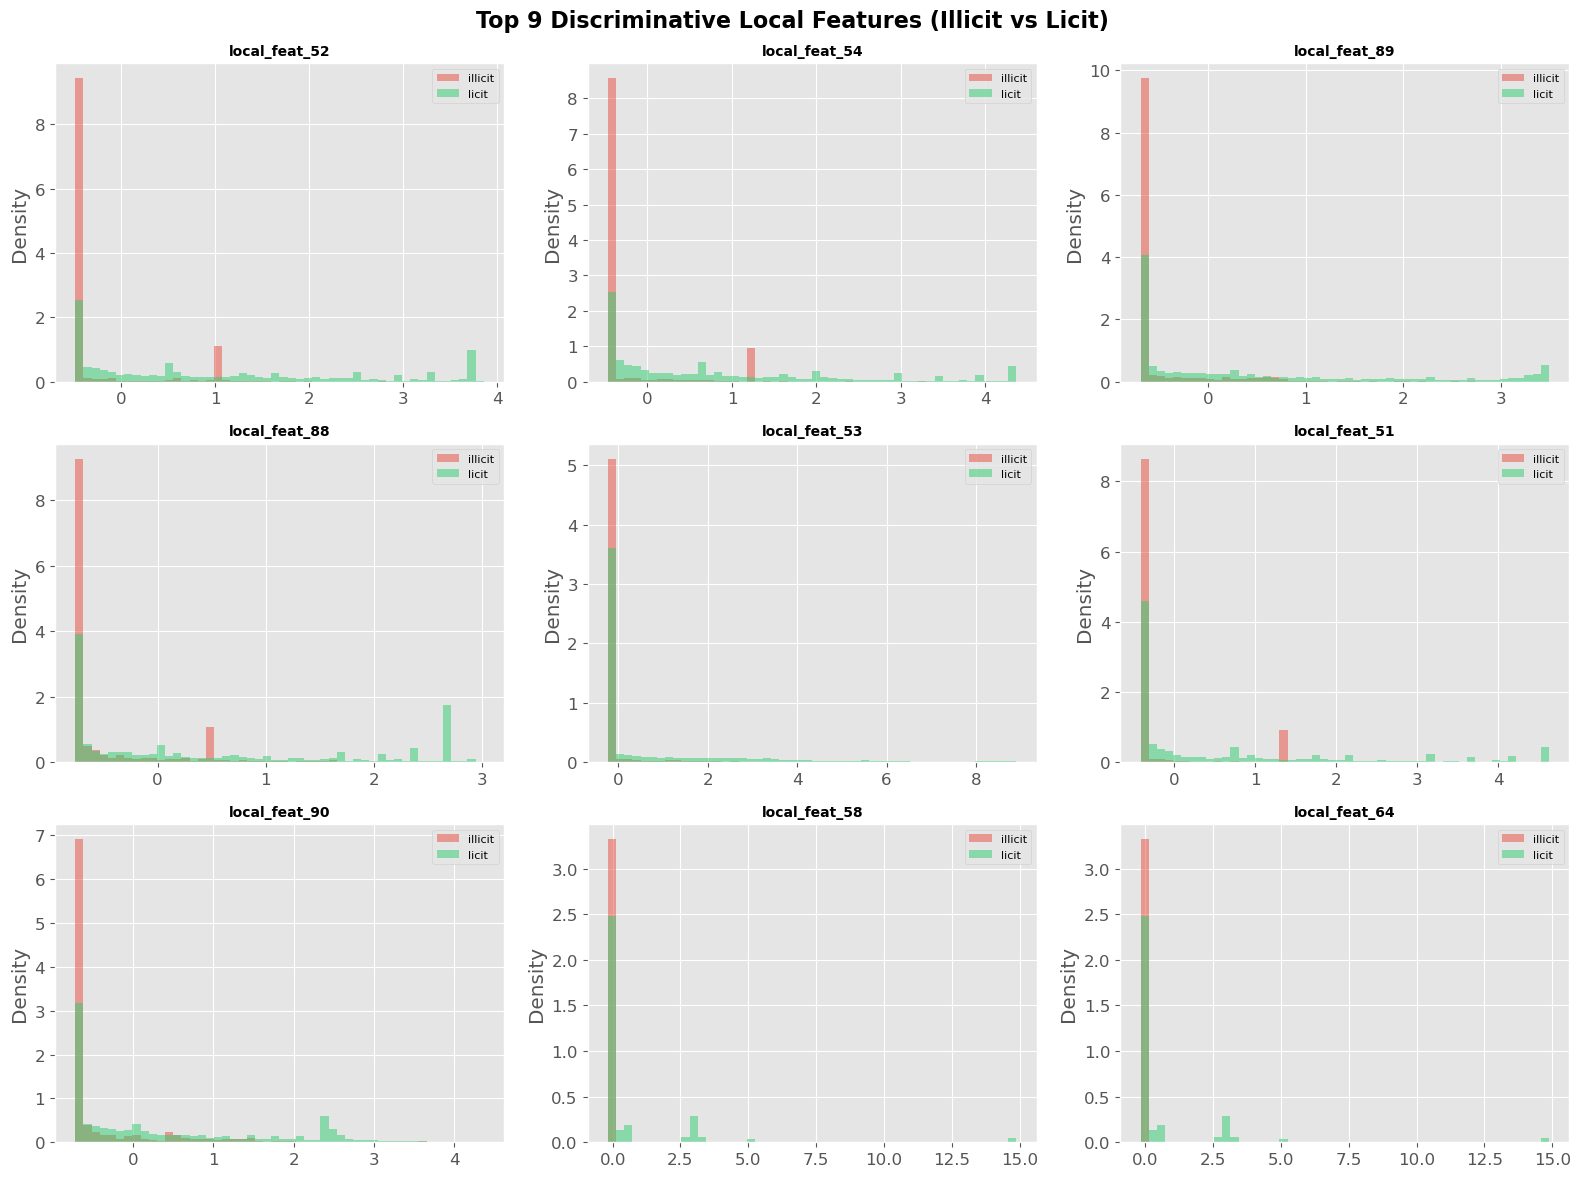

Saved: local_feature_distributions.png


In [ ]:
# ── 8. Local Feature Distribution: Illicit vs Licit ──

local_feat_cols = [c for c in df.columns if c.startswith('local_feat_')]
labeled = df[df['class'].isin(['illicit', 'licit'])]

# Find discriminative features, skip zero-variance and mostly-same-value features
feat_diffs = []
for col in local_feat_cols:
    illicit_data = labeled[labeled['class'] == 'illicit'][col].dropna()
    licit_data = labeled[labeled['class'] == 'licit'][col].dropna()
    
    if len(illicit_data) == 0 or len(licit_data) == 0:
        continue
    if illicit_data.std() == 0 and licit_data.std() == 0:
        continue
    all_data = labeled[col].dropna()
    if len(all_data) == 0:
        continue
    most_common_pct = all_data.value_counts(normalize=True).iloc[0]
    if most_common_pct > 0.90:
        continue
    
    diff = abs(illicit_data.mean() - licit_data.mean())
    feat_diffs.append((col, diff))

# Pick top 9 features with highest mean difference between classes

feat_diffs.sort(key=lambda x: x[1], reverse=True)
top_features = [f[0] for f in feat_diffs[:9]]
print(f"Selected {len(top_features)} features from {len(feat_diffs)} valid features")
print("Top features:", top_features)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Top 9 Discriminative Local Features (Illicit vs Licit)', fontsize=16, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    all_data = labeled[feat].dropna()
    lower = all_data.quantile(0.01)
    upper = all_data.quantile(0.99)
    bins = np.linspace(lower, upper, 51)
    
    for cls, color in [('illicit', '#e74c3c'), ('licit', '#2ecc71')]:
        data = labeled[labeled['class'] == cls][feat].dropna()
        data_clipped = data[(data >= lower) & (data <= upper)]
        if len(data_clipped) > 0:
            ax.hist(data_clipped, bins=bins, alpha=0.5, color=color, label=cls, density=True)
    
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

# Hide unused subplots
for ax in axes.flat[len(top_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'local_feature_distributions.png'), dpi=200, bbox_inches='tight')
plt.show()
print("Saved: local_feature_distributions.png")